In [11]:
!pip install catboost

# Import Libraries

In [12]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)

from sklearn.metrics import (
    brier_score_loss
)

from sklearn.linear_model import LogisticRegression

from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV

from utils.models import get_models
from utils.nested_cv import run_outer_fold_loop
from utils.evaluation import evaluate_model, evaluate_outer_fold

from utils.optimization import(
    get_param_dist,
    get_search_iter,
    tune_model
)

from utils.pipeline import(
    create_pipeline,
    save_fold_predictions,
    select_best_threshold
)
import shap

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load dataset, joblib and model

In [13]:
ds = pd.read_csv("/content/DiabeticCKD_engineered.csv")

X = ds.drop("CKD", axis=1)
y = ds["CKD"]

In [14]:
DS2_SELECTED_MODEL = "LightGBM"

In [15]:
OUTPUT_DIR = "/content/DiabeticCKD_calibration"

os.makedirs(OUTPUT_DIR, exist_ok=True)

fold_plots_ds2_dir = os.path.join(
    OUTPUT_DIR,
    "fold_plots"
)

os.makedirs(
    fold_plots_ds2_dir,
    exist_ok=True
)

# Find calibration slope and intercept

In [16]:
def calibration_slope_intercept(y_true, probabilities):
    eps = 1e-12
    p = np.clip(probabilities, eps, 1 - eps)

    logits = np.log(p / (1 - p)).reshape(-1, 1)
    lr = LogisticRegression(solver="lbfgs")
    lr.fit(logits, np.asarray(y_true).ravel())

    slope = float(np.asarray(lr.coef_).ravel()[0])
    intercept = float(np.asarray(lr.intercept_).ravel()[0])

    return slope, intercept


def evaluate_calibration(y_true, probabilities):
    brier = brier_score_loss(
        y_true,
        probabilities
    )

    slope, intercept = calibration_slope_intercept(
        y_true,
        probabilities
    )

    return {
        "Brier": brier,
        "Slope": slope,
        "Intercept": intercept
    }

# Plot calibration curve

In [17]:
def plot_calibration(y_true, probs_before, probs_after, title, save_path=None, calibrated_label="Calibrated"):

    frac_before, mean_before = calibration_curve(
        y_true,
        probs_before,
        n_bins=10,
        strategy="quantile"
    )

    frac_after, mean_after = calibration_curve(
        y_true,
        probs_after,
        n_bins=10,
        strategy="quantile"
    )

    plt.figure(figsize=(6,6))
    plt.plot(
        [0,1],
        [0,1],
        "--",
        color="black",
        label="Perfect"
    )

    plt.plot(
        mean_before,
        frac_before,
        "o-",
        label="Original"
    )

    plt.plot(
        mean_after,
        frac_after,
        "o-",
        label=calibrated_label
    )

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(title)

    plt.legend()
    plt.grid()

    plt.tight_layout()

    if save_path is not None:

        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True
        )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close()

# Final Overall Plot

In [18]:
def plot_overall_calibration(y_true, original_probs, isotonic_probs, sigmoid_probs, title, save_path=None):

    frac_original, mean_original = calibration_curve(
        y_true,
        original_probs,
        n_bins=10,
        strategy="quantile"
    )

    frac_isotonic, mean_isotonic = calibration_curve(
        y_true,
        isotonic_probs,
        n_bins=10,
        strategy="quantile"
    )

    frac_sigmoid, mean_sigmoid = calibration_curve(
        y_true,
        sigmoid_probs,
        n_bins=10,
        strategy="quantile"
    )

    plt.figure(figsize=(6, 6))

    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black",
        label="Perfect"
    )

    plt.plot(
        mean_original,
        frac_original,
        "o-",
        label="Original"
    )

    plt.plot(
        mean_isotonic,
        frac_isotonic,
        "o-",
        label="Isotonic"
    )

    plt.plot(
        mean_sigmoid,
        frac_sigmoid,
        "o-",
        label="Platt (Sigmoid)"
    )

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(title)

    plt.legend()
    plt.grid()

    plt.tight_layout()

    if save_path is not None:

        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True
        )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close()

In [19]:
model_dir = "/content/saved_models/LightGBM"
fold_dir = "/content/fold_pred/LightGBM"

m = joblib.load(f"{model_dir}/{DS2_SELECTED_MODEL}_fold1.joblib")
print(type(m))

f = joblib.load(f"{fold_dir}/fold1.joblib")
print(f.keys())

<class 'sklearn.pipeline.Pipeline'>
dict_keys(['fold', 'best_pipeline', 'best_params', 'threshold', 'train_indices', 'test_indices', 'inner_best_score', 'y_true', 'y_prob', 'y_pred'])


# Calibration for CKD dataset

Fold 1: Isotonic


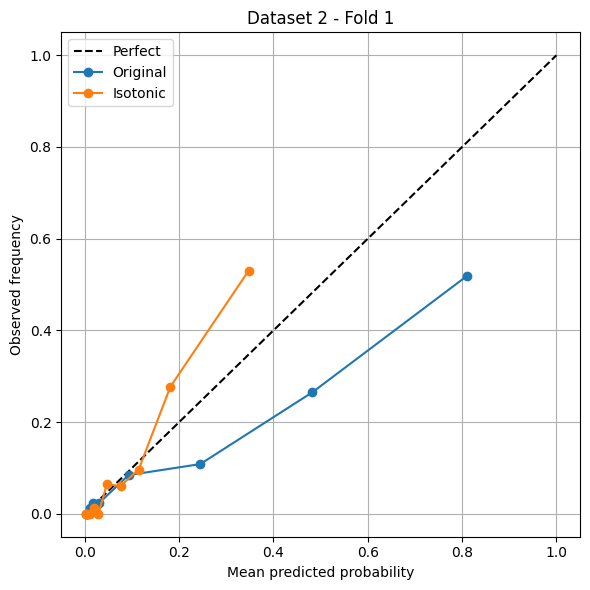

Fold 2: Isotonic


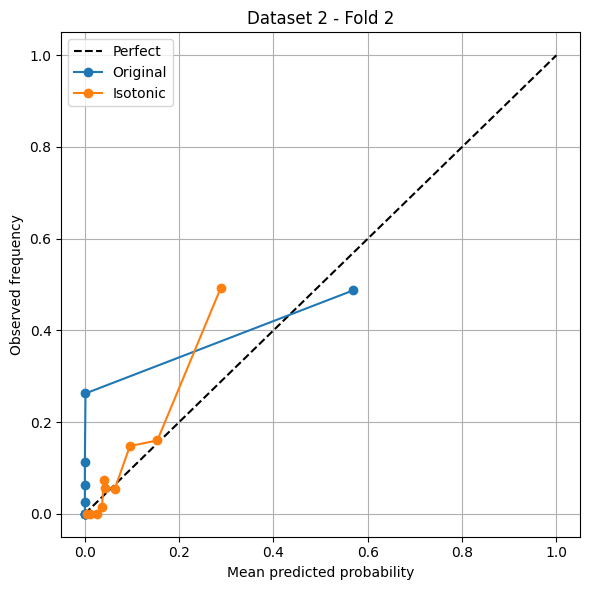

Fold 3: Original


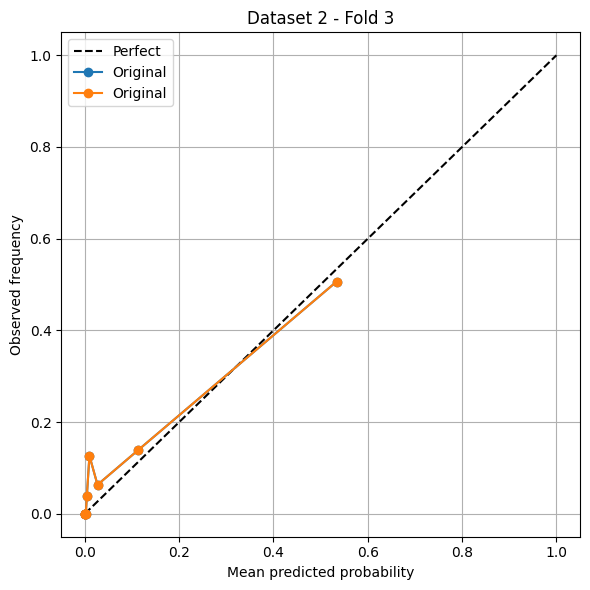

Fold 4: Isotonic


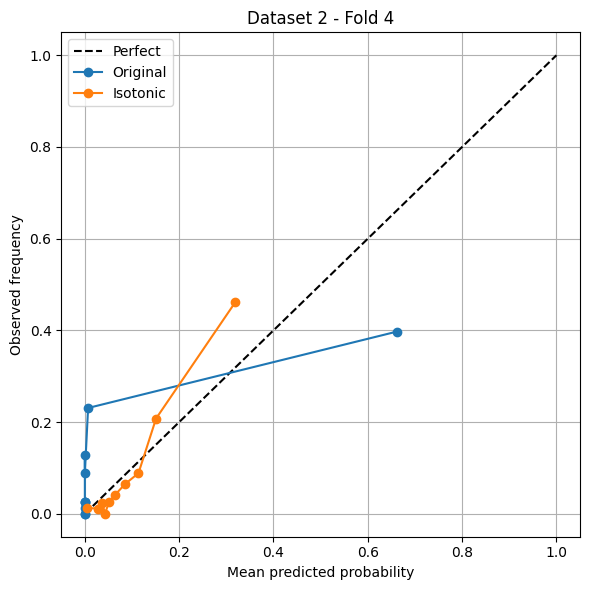

Fold 5: Isotonic


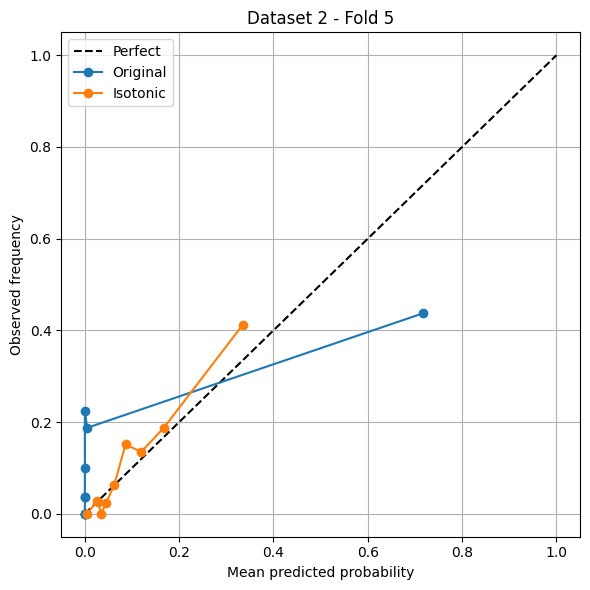

In [20]:
results_ds2 = []
calibration_predictions_ds2 = []

for fold in range(1, 6):

    model = joblib.load(f"{model_dir}/{DS2_SELECTED_MODEL}_fold{fold}.joblib")
    fold_data = joblib.load(f"{fold_dir}/fold{fold}.joblib")

    train_idx = fold_data["train_indices"]
    test_idx = fold_data["test_indices"]

    # Reconstruct outer train/test data
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    original_probs = model.predict_proba(X_test)[:,1]

    isotonic = CalibratedClassifierCV(
        estimator=model,
        method="isotonic",
        cv=3
    )

    isotonic.fit(X_train, y_train)

    isotonic_probs = isotonic.predict_proba(X_test)[:, 1]

    sigmoid = CalibratedClassifierCV(
        estimator=model,
        method="sigmoid",
        cv=3
    )

    sigmoid.fit(X_train, y_train)
    sigmoid_probs = sigmoid.predict_proba(X_test)[:,1]

    original_metrics = evaluate_calibration(
        y_test,
        original_probs
    )

    isotonic_metrics = evaluate_calibration(
        y_test,
        isotonic_probs
    )

    sigmoid_metrics = evaluate_calibration(
        y_test,
        sigmoid_probs
    )

    methods = {
        "Original": original_metrics,
        "Isotonic": isotonic_metrics,
        "Sigmoid": sigmoid_metrics
    }

    best_method = min(
        methods,
        key=lambda x: methods[x]["Brier"]
    )

    print(f"Fold {fold}:", best_method)

    if best_method == "Original":
        calibrated_probs = original_probs

    elif best_method == "Isotonic":
        calibrated_probs = isotonic_probs

    else:
        calibrated_probs = sigmoid_probs

    plot_calibration(
        y_test,
        original_probs,
        calibrated_probs,
        f"Dataset 2 - Fold {fold}",
        save_path=os.path.join(
            fold_plots_ds2_dir,
            f"calibration_fold{fold}.png"
        ),
        calibrated_label=best_method
    )

    results_ds2.append({
        "Fold": fold,
        "Best Method": best_method,

        "Original Brier": original_metrics["Brier"],
        "Original Slope": original_metrics["Slope"],
        "Original Intercept": original_metrics["Intercept"],

        "Isotonic Brier": isotonic_metrics["Brier"],
        "Isotonic Slope": isotonic_metrics["Slope"],
        "Isotonic Intercept": isotonic_metrics["Intercept"],

        "Sigmoid Brier": sigmoid_metrics["Brier"],
        "Sigmoid Slope": sigmoid_metrics["Slope"],
        "Sigmoid Intercept": sigmoid_metrics["Intercept"]
    })

    calibration_predictions_ds2.append({
        "fold": fold,
        "test_indices": test_idx,
        "y_true": np.asarray(y_test),
        "original_probs": original_probs,
        "isotonic_probs": isotonic_probs,
        "sigmoid_probs": sigmoid_probs,
        "best_method": best_method
    })

# Overall calibration

In [21]:
all_y_true_ds2 = np.concatenate([
    x["y_true"]
    for x in calibration_predictions_ds2
])

all_original_probs_ds2 = np.concatenate([
    x["original_probs"]
    for x in calibration_predictions_ds2
])

all_isotonic_probs_ds2 = np.concatenate([
    x["isotonic_probs"]
    for x in calibration_predictions_ds2
])

all_sigmoid_probs_ds2 = np.concatenate([
    x["sigmoid_probs"]
    for x in calibration_predictions_ds2
])

# Overall plot

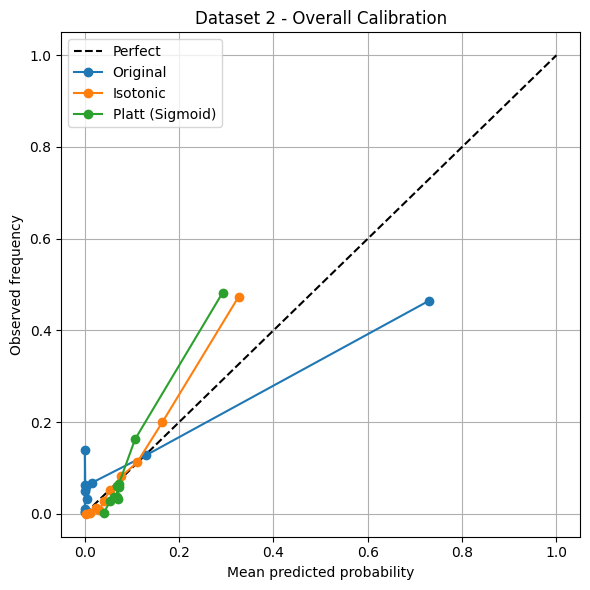

In [22]:
plot_overall_calibration(
    all_y_true_ds2,
    all_original_probs_ds2,
    all_isotonic_probs_ds2,
    all_sigmoid_probs_ds2,
    "Dataset 2 - Overall Calibration",
    save_path=os.path.join(
        OUTPUT_DIR,
        "calibration_curve_overall.png"
    )
)

# Final held-out calibration comparison

In [23]:
pooled_original = evaluate_calibration(
    all_y_true_ds2,
    all_original_probs_ds2
)

pooled_isotonic = evaluate_calibration(
    all_y_true_ds2,
    all_isotonic_probs_ds2
)

pooled_sigmoid = evaluate_calibration(
    all_y_true_ds2,
    all_sigmoid_probs_ds2
)

pooled_methods = {
    "Original": pooled_original,
    "Isotonic": pooled_isotonic,
    "Sigmoid": pooled_sigmoid
}

# Select calibration only if it improves held-out Brier score
final_method = min(
    pooled_methods,
    key=lambda method: pooled_methods[method]["Brier"]
)

print("\nFinal calibration result")
print("------------------------")

for method, metrics in pooled_methods.items():

    print(
        f"{method}: "
        f"Brier={metrics['Brier']:.4f}, "
        f"Slope={metrics['Slope']:.4f}, "
        f"Intercept={metrics['Intercept']:.4f}"
    )

print(f"\nFinal method: {final_method}")


Final calibration result
------------------------
Original: Brier=0.0778, Slope=0.1754, Intercept=-1.0788
Isotonic: Brier=0.0672, Slope=1.4734, Intercept=1.0484
Sigmoid: Brier=0.0710, Slope=1.7249, Intercept=1.5718

Final method: Isotonic


# Save result

In [24]:
results_ds2_df = pd.DataFrame(results_ds2)

results_ds2_df.to_csv(
    f"{OUTPUT_DIR}/experiment5_calibration_fold_results.csv",
    index=False,
    encoding='utf-8-sig'
)

joblib.dump(
    calibration_predictions_ds2,
    f"{OUTPUT_DIR}/experiment5_calibration_predictions.joblib"
)

['/content/DiabeticCKD_calibration/experiment5_calibration_predictions.joblib']

# Summary

In [25]:
summary_ds2 = pd.DataFrame({
    "Method": [
        "Original",
        "Isotonic",
        "Sigmoid"
    ],

    "Mean_Brier": [
        results_ds2_df["Original Brier"].mean(),
        results_ds2_df["Isotonic Brier"].mean(),
        results_ds2_df["Sigmoid Brier"].mean()
    ],

    "SD_Brier": [
        results_ds2_df["Original Brier"].std(),
        results_ds2_df["Isotonic Brier"].std(),
        results_ds2_df["Sigmoid Brier"].std()
    ],

    "Mean_Slope": [
        results_ds2_df["Original Slope"].mean(),
        results_ds2_df["Isotonic Slope"].mean(),
        results_ds2_df["Sigmoid Slope"].mean()
    ],

    "SD_Slope": [
        results_ds2_df["Original Slope"].std(),
        results_ds2_df["Isotonic Slope"].std(),
        results_ds2_df["Sigmoid Slope"].std()
    ],

    "Mean_Intercept": [
        results_ds2_df["Original Intercept"].mean(),
        results_ds2_df["Isotonic Intercept"].mean(),
        results_ds2_df["Sigmoid Intercept"].mean()
    ],

    "SD_Intercept": [
        results_ds2_df["Original Intercept"].std(),
        results_ds2_df["Isotonic Intercept"].std(),
        results_ds2_df["Sigmoid Intercept"].std()
    ]
})

display(summary_ds2)

summary_ds2.to_csv(
    f"{OUTPUT_DIR}/DiabeticCKD_calibration_summary.csv",
    index=False,
    encoding='utf-8-sig'
)

,Method,Mean_Brier,SD_Brier,Mean_Slope,SD_Slope,Mean_Intercept,SD_Intercept
0,Original,0.077752,0.013280,0.376270,0.292623,-0.471683,0.404311
1,Isotonic,0.067132,0.005977,1.468042,0.146665,1.036077,0.290908
2,Sigmoid,0.070995,0.006904,1.729674,0.272329,1.587063,0.567691
